# Project 2: Dijkstra's algorithm
**SC2001 — Algorithm Design and Analysis**

This notebook implements the two settings in [Project 2.pdf](Project%202.pdf):

1. Build a graph and convert it to an adjacency matrix or an adjacency list.
2. **Part A:** adjacency matrix + unsorted array priority queue.
3. **Part B:** adjacency list + indexed binary min-heap priority queue.
4. **Part C:** compare theoretical bounds and empirical operation counts.

Both algorithms follow **slide 16** of [06_ShortestPath.pdf](06_ShortestPath.pdf): initialize distances and parents; insert **all vertices** into the priority queue; repeatedly extract the minimum and relax every outgoing edge. `relax` follows slide 9. Slide numbers here are the numbers printed on the slides; the PDF contains additional animation pages.

**Notation:** $V$ denotes the number of vertices and $E$ the number of directed edges. We use simple directed graphs without self-loops, with finite, nonnegative weights. Zero-weight edges and unreachable vertices are supported.

**Run:** Python 3.10+ with `numpy`, `pandas`, `matplotlib`, and a Jupyter Python kernel. Select **Restart Kernel and Run All**. All results and figures below are saved outputs; graph generation is reproducible using fixed seeds.

In [1]:
from dataclasses import dataclass, asdict
from math import inf, isfinite, log2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

## 1. Graph representation and conversions

We start with an **edge list**: each `(u, v, weight)` describes an edge from vertex `u` to vertex `v`. Both algorithms use the same edges.

* **Adjacency matrix:** a $V \times V$ table. Each cell stores an edge weight, or `None` if there is no edge. Creating the table takes $O(V^2)$, then filling in the edges takes $O(E)$. Total: **$O(V^2 + E)$ time** and **$O(V^2)$ space**.
* **Adjacency list:** one list per vertex, containing only its outgoing edges. Creating $V$ lists and adding $E$ edges takes **$O(V + E)$ time and space**.

Here, $V$ means the number of vertices and $E$ means the number of directed edges. Graph generation and conversion are not included in the Dijkstra operation counts below.


In [2]:
@dataclass(frozen=True)
class Graph:
    n: int
    edges: tuple

    def __post_init__(self):
        if not isinstance(self.n, int) or self.n < 1:
            raise ValueError('The graph must have at least one vertex.')
        object.__setattr__(self, 'edges', tuple(tuple(e) for e in self.edges))
        seen = set()
        for u, v, weight in self.edges:
            if not (isinstance(u, int) and isinstance(v, int)
                    and 0 <= u < self.n and 0 <= v < self.n):
                raise ValueError('Vertex IDs must be integers in range(n).')
            if u == v or (u, v) in seen:
                raise ValueError('Self-loops and duplicate directed edges are excluded.')
            if not isinstance(weight, (int, float)) or not isfinite(weight) or weight < 0:
                raise ValueError('Dijkstra requires finite, nonnegative weights.')
            seen.add((u, v))

    @property
    def m(self):
        return len(self.edges)


def to_adjacency_matrix(graph):
    matrix = [[None] * graph.n for _ in range(graph.n)]
    for u, v, weight in graph.edges:
        matrix[u][v] = weight
    return matrix


def to_adjacency_list(graph):
    adjacency = [[] for _ in range(graph.n)]
    for u, v, weight in graph.edges:
        adjacency[u].append((v, weight))
    return adjacency


example = Graph(6, ((0, 1, 7), (0, 2, 9), (0, 5, 14),
                    (1, 2, 10), (1, 3, 15), (2, 3, 11),
                    (2, 5, 2), (3, 4, 6), (5, 4, 9)))
print('Edge list:', example.edges)
print('Matrix (None means no edge):')
for row in to_adjacency_matrix(example):
    print(row)
print('Adjacency list:', to_adjacency_list(example))

Edge list: ((0, 1, 7), (0, 2, 9), (0, 5, 14), (1, 2, 10), (1, 3, 15), (2, 3, 11), (2, 5, 2), (3, 4, 6), (5, 4, 9))
Matrix (None means no edge):
[None, 7, 9, None, None, 14]
[None, None, 10, 15, None, None]
[None, None, None, 11, None, 2]
[None, None, None, None, 6, None]
[None, None, None, None, None, None]
[None, None, None, None, 9, None]
Adjacency list: [[(1, 7), (2, 9), (5, 14)], [(2, 10), (3, 15)], [(3, 11), (5, 2)], [(4, 6)], [], [(4, 9)]]


### What should we measure?

We count the work each algorithm does as the graph gets larger. This helps us check whether the results follow the expected time complexity.

The main work is:

| Part A: matrix + array | Part B: list + heap |
|---|---|
| Scan the queue to find the nearest vertex | Use the heap to find the nearest vertex |
| Check matrix cells for outgoing edges | Visit existing edges in the adjacency list |
| Check and update distances | Check and update distances, then fix the heap when needed |

We include queue work because it is a major reason the algorithms have different complexities. Counting only edge checks would miss this difference.

The code keeps detailed counters and adds them into one **operation count**. A lower count means less work under this counting method; it does not directly tell us how many seconds an algorithm takes.


In [3]:
@dataclass
class Counts:
    initializations: int = 0
    queue_items: int = 0
    extractions: int = 0
    array_comparisons: int = 0
    matrix_probes: int = 0
    list_entries: int = 0
    relax_checks: int = 0
    distance_updates: int = 0
    heap_comparisons: int = 0
    heap_swaps: int = 0
    decrease_keys: int = 0

    @property
    def total(self):
        return sum(asdict(self).values())


def initialize(n, source, counts):
    if not 0 <= source < n:
        raise ValueError('Source vertex is out of range.')
    dist, parent = [inf] * n, [None] * n
    counts.initializations += n
    dist[source] = 0
    return dist, parent


def relax(u, v, weight, dist, parent, counts):
    # Slide 9: if dist[v] > dist[u] + weight, update parent and distance.
    counts.relax_checks += 1
    candidate = dist[u] + weight
    if dist[v] > candidate:
        parent[v], dist[v] = u, candidate
        counts.distance_updates += 1
        return True
    return False


def reconstruct_path(parent, dist, target):
    if dist[target] == inf:
        return None
    path = []
    while target is not None:
        path.append(target)
        target = parent[target]
    return path[::-1]

### Experimental design

Both algorithms run on the same graphs, starting from vertex 0. We use three fixed random seeds per setting and edge weights from 1 to 100.

* **Increase vertices:** double $V$ from 24 to 384. Sparse graphs use $E = 4V$; dense graphs use about $V^2/2$ edges.
* **Increase edges:** keep $V = 192$ and add edges. This shows how graph density affects the work.

The experiment graphs are built so every vertex is reachable. Separate tests check disconnected graphs and zero-weight edges. Graph construction and correctness checks are excluded from the operation counts.

The plots show the average count across three seeds, with error bars showing the variation. All axes use linear scales. The results illustrate these inputs; the theoretical analysis explains the general bounds.


In [4]:
def random_graph(n, m, seed):
    if not n - 1 <= m <= n * (n - 1):
        raise ValueError('This generator requires n-1 <= m <= n(n-1).')
    rng = random.Random(seed)
    order = [0] + rng.sample(list(range(1, n)), n - 1)
    backbone = list(zip(order, order[1:]))
    used = set(backbone)
    candidates = [(u, v) for u in range(n) for v in range(n)
                  if u != v and (u, v) not in used]
    pairs = backbone + rng.sample(candidates, m - len(backbone))
    return Graph(n, tuple((u, v, rng.randint(1, 100)) for u, v in pairs))


SEEDS = (11, 29, 47)
VERTICES = (24, 48, 96, 192, 384)
FIXED_V = 192
EDGE_COUNTS = (191, 384, 768, 1536, 3072, 6144, 12288, 24576, 36672)
datasets = []
for family in ('sparse', 'dense'):
    for n in VERTICES:
        m = 4 * n if family == 'sparse' else n * (n - 1) // 2
        for seed in SEEDS:
            datasets.append(('V sweep', family, seed, random_graph(n, m, seed)))
for m in EDGE_COUNTS:
    for seed in SEEDS:
        datasets.append(('E sweep', 'fixed V', seed, random_graph(FIXED_V, m, seed)))


def run_experiment(algorithm, convert):
    rows = []
    for sweep, family, seed, graph in datasets:
        representation = convert(graph)
        dist, parent, counts = algorithm(representation, 0)
        assert all(d < inf for d in dist)
        assert counts.extractions == graph.n
        assert counts.relax_checks == graph.m
        rows.append(dict(sweep=sweep, family=family, seed=seed,
                         V=graph.n, E=graph.m, total=counts.total,
                         **asdict(counts)))
    return pd.DataFrame(rows)


def summarize(frame):
    return frame.groupby(['sweep', 'family', 'V', 'E'], sort=False).agg(
        mean_ops=('total', 'mean'), sd_ops=('total', 'std'),
        mean_updates=('distance_updates', 'mean')).reset_index()


def plot_experiment(frame, title, heap=False):
    summary = summarize(frame)
    for family in ('sparse', 'dense'):
        fig, ax = plt.subplots(figsize=(7, 4.5))
        subset = summary[(summary.sweep == 'V sweep') & (summary.family == family)]
        x = subset.V.to_numpy()
        ax.errorbar(x, subset.mean_ops, yerr=subset.sd_ops, marker='o', capsize=3,
                    label='Measured work')
        reference = ((subset.V + subset.E) * np.log2(subset.V)).to_numpy() if heap else x**2
        scaled = reference * subset.mean_ops.iloc[0] / reference[0]
        ax.plot(x, scaled, '--', label='Scaled (V+E) log₂ V bound' if heap else 'Scaled V²')
        ax.set(xscale='linear', yscale='linear', xlabel='V (linear scale)', ylabel='Core-operation score (linear scale)',
               title=title + '\n' + family.capitalize() + ' graphs')
        ax.set_xticks(x, labels=[str(v) for v in x])
        ax.minorticks_off()
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    fig, ax = plt.subplots(figsize=(7, 4.5))
    subset = summary[summary.sweep == 'E sweep']
    ax.errorbar(subset.E, subset.mean_ops, yerr=subset.sd_ops, marker='o', capsize=3)
    ax.set(xlabel='E (linear scale)', ylabel='Core-operation score (linear scale)', title=title + f'\nFixed V = {FIXED_V}')
    plt.tight_layout()
    plt.show()
    return summary

## Part A — Adjacency matrix and array priority queue

### How it works

The queue is an unsorted list of vertices that have not been processed yet. Each iteration:

1. **Find the nearest vertex:** scan the queue and choose the vertex with the smallest distance.
2. **Find its neighbors:** scan its entire matrix row, including cells where no edge exists.
3. **Update distances:** for each existing edge, check whether going through this vertex gives a shorter path. This check is called **relaxation**.

An update just writes the new distance and parent. No sorting is needed because the next queue scan reads the updated distances. The algorithm repeats until all vertices have been processed.


In [5]:
def dijkstra_matrix(matrix, source):
    # Input is a square matrix produced by to_adjacency_matrix(Graph(...)).
    n = len(matrix)
    counts = Counts()
    dist, parent = initialize(n, source, counts)  # Slide 16, line 1
    Q = list(range(n))                          # Line 2: all vertices
    counts.queue_items += n
    while Q:                                   # Line 3
        best = 0
        for i in range(1, len(Q)):
            counts.array_comparisons += 1
            if (dist[Q[i]], Q[i]) < (dist[Q[best]], Q[best]):
                best = i
        u = Q[best]                            # Line 4: extract minimum
        Q[best] = Q[-1]
        Q.pop()
        counts.extractions += 1
        for v in range(n):                     # Line 5: discover outgoing edges
            counts.matrix_probes += 1
            weight = matrix[u][v]
            if weight is not None:
                relax(u, v, weight, dist, parent, counts)  # Line 6
    return dist, parent, counts


dist_a, parent_a, counts_a = dijkstra_matrix(to_adjacency_matrix(example), 0)
assert dist_a == [0, 7, 9, 20, 20, 11]
display(pd.DataFrame({'vertex': range(example.n), 'distance': dist_a,
                      'parent': parent_a,
                      'path': [reconstruct_path(parent_a, dist_a, v)
                               for v in range(example.n)]}))
print('Operation counts:', asdict(counts_a))

,vertex,distance,parent,path
0,0,0,NaN,[0]
1,1,7,0.0,"[0, 1]"
2,2,9,0.0,"[0, 2]"
3,3,20,2.0,"[0, 2, 3]"
4,4,20,5.0,"[0, 2, 5, 4]"
5,5,11,2.0,"[0, 2, 5]"


Operation counts: {'initializations': 6, 'queue_items': 6, 'extractions': 6, 'array_comparisons': 15, 'matrix_probes': 36, 'list_entries': 0, 'relax_checks': 9, 'distance_updates': 7, 'heap_comparisons': 0, 'heap_swaps': 0, 'decrease_keys': 0}


### Why Part A takes $O(V^2)$ time

There are $V$ iterations because each iteration processes one vertex. Two steps account for most of the work:

| Main step | Work per iteration | Total work |
|---|---|---|
| Find the smallest distance in the unsorted queue | Scan up to $V$ vertices | $O(V^2)$ |
| Find neighbors in the matrix row | Check all $V$ cells | $V \times V = V^2$ |

The queue gets shorter each time, but scanning $V$, then $V-1$, then $V-2$, and so on still adds up to quadratic work. The matrix scan is simpler: **$V$ rows, with $V$ cells in each row**.

Checking and updating an edge takes $O(1)$, so processing the edges adds $O(E)$. The total is therefore $O(V^2 + E)$. A simple directed graph has at most $V(V-1)$ edges, so this simplifies to **$O(V^2)$**. In fact, the full matrix scans make the bound tight: $\Theta(V^2)$.

**Key idea:** even when there are very few edges, Part A still scans the whole matrix and repeatedly searches the queue. Doubling the number of vertices gives roughly four times as much work.

The matrix uses $O(V^2)$ space; the distance, parent, and queue arrays use $O(V)$ extra space.


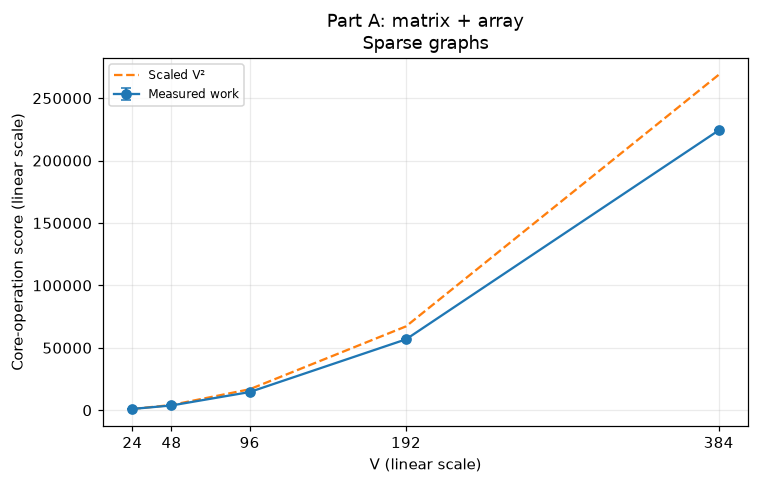

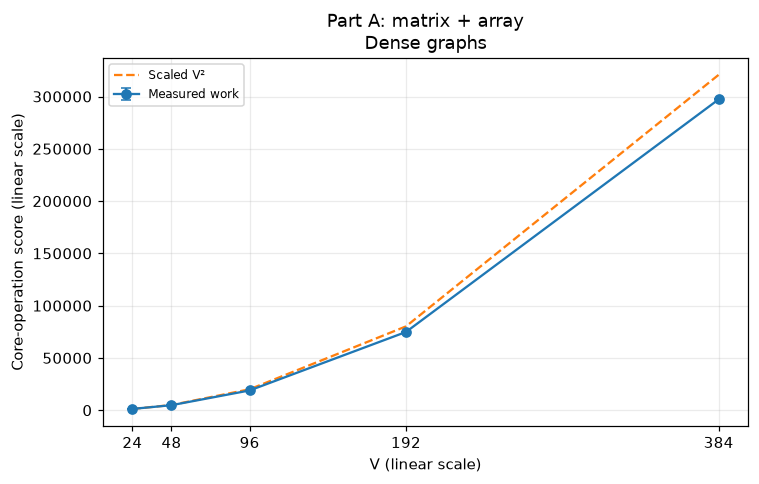

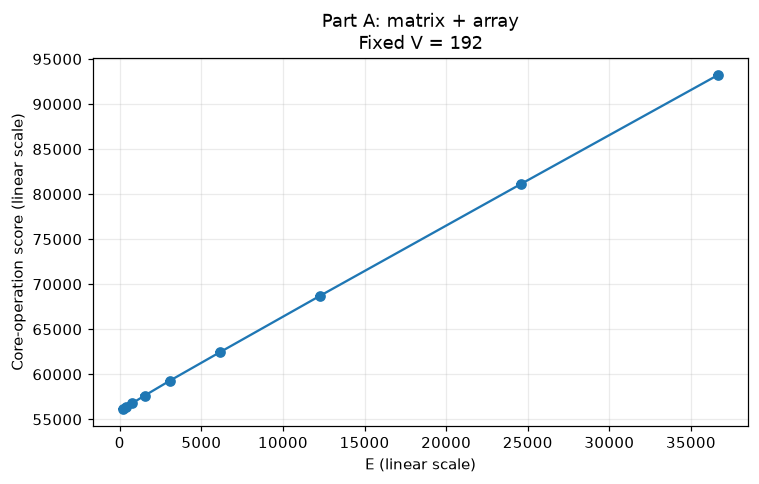

,sweep,family,V,E,mean_ops,sd_ops,mean_updates
0,V sweep,sparse,24,96,1049.67,1.15,29.67
1,V sweep,sparse,48,192,3828.67,4.04,60.67
2,V sweep,sparse,96,384,14574.00,1.00,126.00
3,V sweep,sparse,192,768,56797.00,6.00,253.00
4,V sweep,sparse,384,1536,224191.67,11.85,511.67
5,V sweep,dense,24,276,1253.00,4.58,53.00
6,V sweep,dense,48,1128,4824.67,3.21,120.67
7,V sweep,dense,96,4560,18934.33,28.57,310.33
8,V sweep,dense,192,18336,74841.67,5.86,729.67
9,V sweep,dense,384,73536,297283.67,23.09,1603.67


sparse: fitted log-log slope = 1.937; quadratic prediction = 2
dense: fitted log-log slope = 1.974; quadratic prediction = 2


In [6]:
results_a = run_experiment(dijkstra_matrix, to_adjacency_matrix)
assert (results_a.matrix_probes == results_a.V ** 2).all()
assert (results_a.array_comparisons == results_a.V * (results_a.V - 1) // 2).all()
assert (results_a.total == 3 * results_a.V + results_a.V * (results_a.V - 1) // 2
        + results_a.V**2 + results_a.E + results_a.distance_updates).all()
summary_a = plot_experiment(results_a, 'Part A: matrix + array')
display(summary_a.round(2))
for family in ('sparse', 'dense'):
    subset = summary_a[(summary_a.sweep == 'V sweep') & (summary_a.family == family)]
    exponent = np.polyfit(np.log2(subset.V), np.log2(subset.mean_ops), 1)[0]
    print(f'{family}: fitted log-log slope = {exponent:.3f}; quadratic prediction = 2')

### Reading Part A's results

* **As $V$ increases:** both sparse and dense graphs show roughly quadratic growth. Doubling $V$ makes the main scan work about four times larger, matching $O(V^2)$.
* **As $E$ increases with $V$ fixed:** the matrix and queue scans stay the same size. More edges add distance checks, so the measured count can still rise.

**Takeaway:** the number of vertices drives Part A's main cost. Having fewer edges does not remove the full matrix scans.


## Part B — Adjacency list and binary min-heap

### How it works

Part B follows the same Dijkstra steps, but changes how it finds vertices and neighbors:

1. **Find the nearest vertex:** remove the smallest-distance vertex from a min-heap.
2. **Find its neighbors:** visit only the edges stored in its adjacency list.
3. **Update distances:** if a shorter path is found, update the distance and move that vertex up the heap to restore its order. This is called **decrease-key**.

The heap holds each unprocessed vertex once. A position array lets the code find a vertex's heap entry directly, without searching through the heap.


In [7]:
class IndexedMinHeap:
    def __init__(self, dist, counts):
        self.dist = dist  # Shared priorities: relax updates this array.
        self.counts = counts
        self.heap = list(range(len(dist)))
        self.position = list(range(len(dist)))
        counts.queue_items += len(dist)
        for i in range(len(self.heap) // 2 - 1, -1, -1):
            self._sift_down(i)

    def __bool__(self):
        return bool(self.heap)

    def _less(self, i, j):
        self.counts.heap_comparisons += 1
        u, v = self.heap[i], self.heap[j]
        return (self.dist[u], u) < (self.dist[v], v)

    def _swap(self, i, j):
        self.counts.heap_swaps += 1
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
        self.position[self.heap[i]] = i
        self.position[self.heap[j]] = j

    def _sift_down(self, i):
        while 2 * i + 1 < len(self.heap):
            child = 2 * i + 1
            right = child + 1
            if right < len(self.heap) and self._less(right, child):
                child = right
            if not self._less(child, i):
                break
            self._swap(i, child)
            i = child

    def extract_min(self):
        self.counts.extractions += 1
        result = self.heap[0]
        last = self.heap.pop()
        self.position[result] = -1
        if self.heap:
            self.heap[0] = last
            self.position[last] = 0
            self._sift_down(0)
        return result

    def decrease_key(self, vertex):
        # The caller has just decreased dist[vertex]. Restore heap order.
        self.counts.decrease_keys += 1
        i = self.position[vertex]
        assert i >= 0, 'An extracted vertex cannot improve with nonnegative weights.'
        while i > 0:
            parent = (i - 1) // 2
            if not self._less(i, parent):
                break
            self._swap(i, parent)
            i = parent


def dijkstra_list(adjacency, source):
    # Input is produced by to_adjacency_list(Graph(...)).
    counts = Counts()
    dist, parent = initialize(len(adjacency), source, counts)  # Line 1
    Q = IndexedMinHeap(dist, counts)                          # Line 2
    while Q:                                                 # Line 3
        u = Q.extract_min()                                  # Line 4
        for v, weight in adjacency[u]:                        # Line 5
            counts.list_entries += 1
            if relax(u, v, weight, dist, parent, counts):      # Line 6
                Q.decrease_key(v)  # Keep Q consistent with changed dist[v].
    return dist, parent, counts


dist_b, parent_b, counts_b = dijkstra_list(to_adjacency_list(example), 0)
assert dist_b == dist_a == [0, 7, 9, 20, 20, 11]
display(pd.DataFrame({'vertex': range(example.n), 'distance': dist_b,
                      'parent': parent_b,
                      'path': [reconstruct_path(parent_b, dist_b, v)
                               for v in range(example.n)]}))
print('Operation counts:', asdict(counts_b))

,vertex,distance,parent,path
0,0,0,NaN,[0]
1,1,7,0.0,"[0, 1]"
2,2,9,0.0,"[0, 2]"
3,3,20,2.0,"[0, 2, 3]"
4,4,20,5.0,"[0, 2, 5, 4]"
5,5,11,2.0,"[0, 2, 5]"


Operation counts: {'initializations': 6, 'queue_items': 6, 'extractions': 6, 'array_comparisons': 0, 'matrix_probes': 0, 'list_entries': 9, 'relax_checks': 9, 'distance_updates': 7, 'heap_comparisons': 20, 'heap_swaps': 6, 'decrease_keys': 7}


### Why Part B takes $O((V + E)\log V)$ time

A binary heap with at most $V$ entries has about $\log_2 V$ levels. Removing the minimum or updating a priority may move an entry through those levels, so either operation takes **$O(\log V)$**.

| Main step | How often it happens | Total work |
|---|---|---|
| Remove the nearest vertex from the heap | Once per vertex: $V$ times | $O(V\log V)$ |
| Visit an edge and check its distance | Once per edge: $E$ times | $O(E)$ |
| Fix the heap after a shorter path is found | At most once per edge: at most $E$ times | $O(E\log V)$ |

Initializing the arrays and building the heap takes $O(V)$, which is smaller than the main terms. Adding the costs gives:

$$O(V\log V + E + E\log V) = \boxed{O((V + E)\log V)}.$$

For graphs where all vertices are reachable, this is also commonly written **$O(E\log V)$**.

* **Sparse graph:** $E$ grows in proportion to $V$, so the bound becomes **$O(V\log V)$**.
* **Dense graph:** $E$ grows in proportion to $V^2$, so the worst-case bound becomes **$O(V^2\log V)$**.

**Key idea:** adjacency lists skip missing edges, and the heap avoids scanning the whole queue. The bound allows for a heap update after every edge check, but an actual run may need fewer updates.

The adjacency lists use $O(V + E)$ space; the arrays and heap use $O(V)$ extra space.


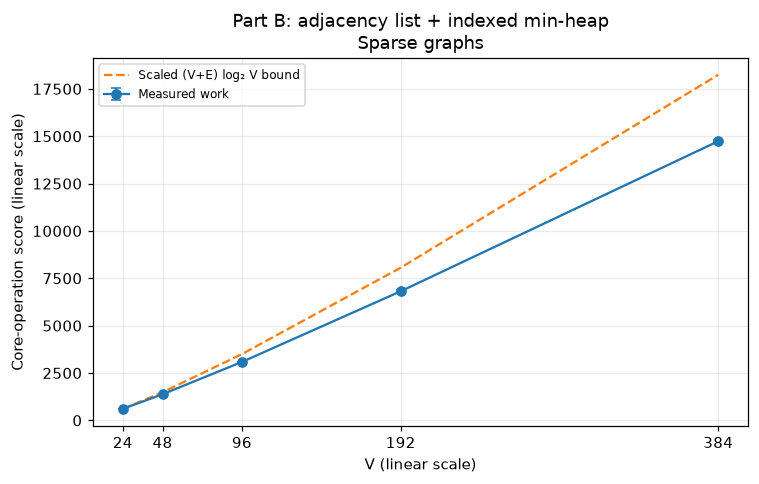

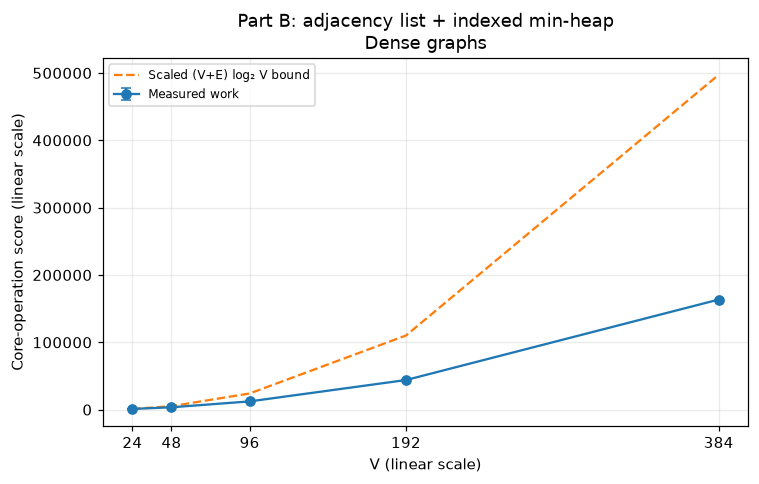

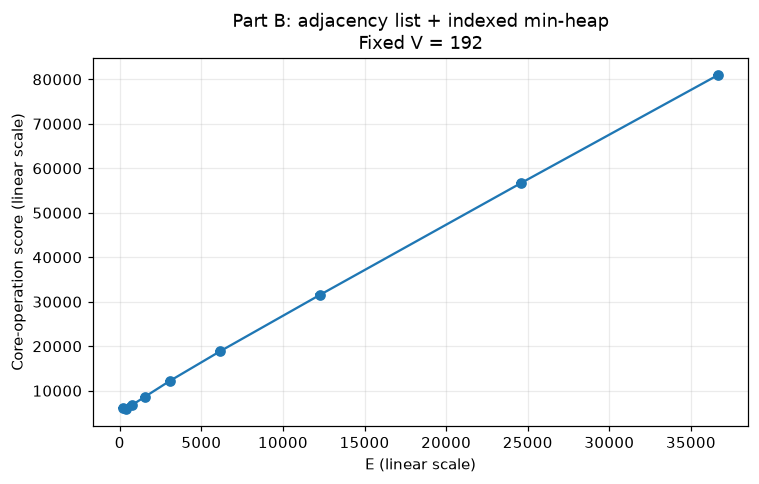

,sweep,family,V,E,mean_ops,sd_ops,mean_updates
0,V sweep,sparse,24,96,609.00,6.24,29.67
1,V sweep,sparse,48,192,1377.00,15.72,60.67
2,V sweep,sparse,96,384,3084.33,21.20,126.00
3,V sweep,sparse,192,768,6814.33,92.18,253.00
4,V sweep,sparse,384,1536,14737.33,57.42,511.67
5,V sweep,dense,24,276,1078.00,9.64,53.00
6,V sweep,dense,48,1128,3509.67,20.31,120.67
7,V sweep,dense,96,4560,12261.33,129.37,310.33
8,V sweep,dense,192,18336,43988.33,43.98,729.67
9,V sweep,dense,384,73536,163496.00,100.85,1603.67


sparse: finite-range fitted log-log slope = 1.150
dense: finite-range fitted log-log slope = 1.814


,list_entries,relax_checks,distance_updates,heap_comparisons,heap_swaps
family,,,,,
dense,19567.2,19567.2,563.5,2839.4,1319.5
fixed V,9514.6,9514.6,466.0,3215.0,1566.0
sparse,595.2,595.2,196.2,2222.3,1072.9


In [8]:
results_b = run_experiment(dijkstra_list, to_adjacency_list)
assert (results_b.list_entries == results_b.E).all()
assert (results_b.decrease_keys == results_b.distance_updates).all()
assert (results_b.total == 3 * results_b.V + 2 * results_b.E
        + 2 * results_b.distance_updates + results_b.heap_comparisons
        + results_b.heap_swaps).all()
summary_b = plot_experiment(results_b, 'Part B: adjacency list + indexed min-heap', heap=True)
display(summary_b.round(2))
for family in ('sparse', 'dense'):
    subset = summary_b[(summary_b.sweep == 'V sweep') & (summary_b.family == family)]
    exponent = np.polyfit(np.log2(subset.V), np.log2(subset.mean_ops), 1)[0]
    print(f'{family}: finite-range fitted log-log slope = {exponent:.3f}')
display(results_b.groupby('family')[['list_entries', 'relax_checks',
        'distance_updates', 'heap_comparisons', 'heap_swaps']].mean().round(1))

### Reading Part B's results

* **Sparse graphs:** with $E = 4V$, the bound is $O(V\log V)$. This grows much more slowly than Part A's $O(V^2)$.
* **Dense graphs:** there are about $V^2$ edges to check. The worst-case bound is $O(V^2\log V)$, but not every edge improves a distance or needs a heap update. The measured work can therefore grow closer to $V^2$.
* **As $E$ increases with $V$ fixed:** Part B visits more edges, so its work increases. The amount of extra heap work depends on how often shorter paths are found.

**Takeaway:** Part B saves work when there are few edges. Its actual count also depends on how many distance updates are needed.


### Correctness checks for both implementations

We compare distances against an independent **Bellman–Ford** implementation (slide 13), and verify that every reconstructed path uses real edges and has the reported weight. Parents need not be identical when several shortest paths exist. Tests include an isolated source, disconnected vertices, zero-weight cycles, tied paths, a vertex whose key improves more than once, and nonzero sources. Invalid graph inputs must be rejected.

In [9]:
def bellman_ford(graph, source):
    dist = [inf] * graph.n
    dist[source] = 0
    for _ in range(graph.n - 1):
        changed = False
        for u, v, weight in graph.edges:
            if dist[u] + weight < dist[v]:
                dist[v] = dist[u] + weight
                changed = True
        if not changed:
            break
    return dist


def check_graph(graph, source):
    expected = bellman_ford(graph, source)
    weights = {(u, v): w for u, v, w in graph.edges}
    for algorithm, convert in ((dijkstra_matrix, to_adjacency_matrix),
                               (dijkstra_list, to_adjacency_list)):
        dist, parent, counts = algorithm(convert(graph), source)
        assert dist == expected
        assert counts.extractions == graph.n
        assert counts.relax_checks == graph.m
        for v in range(graph.n):
            path = reconstruct_path(parent, dist, v)
            if dist[v] == inf:
                assert path is None and parent[v] is None
            else:
                assert path[0] == source and path[-1] == v
                assert len(path) == len(set(path))
                assert sum(weights[u, w] for u, w in zip(path, path[1:])) == dist[v]


cases = [
    (Graph(1, ()), 0),
    (Graph(4, ()), 2),
    (Graph(5, ((0, 1, 2), (2, 3, 0))), 0),
    (Graph(4, ((0, 1, 0), (1, 0, 0), (0, 2, 1),
               (1, 2, 1), (2, 3, 0))), 0),
    (Graph(4, ((0, 1, 10), (0, 2, 1), (2, 1, 1),
               (1, 3, 1), (2, 3, 20))), 0),
    (example, 3),
]
for graph, source in cases:
    check_graph(graph, source)

# Random graphs here need not be reachable; weights include zero.
for seed in range(40):
    rng = random.Random(seed)
    n = rng.randint(2, 20)
    edges = tuple((u, v, rng.randint(0, 12))
                  for u in range(n) for v in range(n)
                  if u != v and rng.random() < 0.2)
    check_graph(Graph(n, edges), rng.randrange(n))

# Validate every actual experimental graph against the independent oracle too.
for _, _, _, graph in datasets:
    check_graph(graph, 0)

invalid_edges = [((0, 1, -1),), ((0, 1, inf),), ((0, 1, float('nan')),),
                 ((0, 0, 1),), ((0, 2, 1),), ((0, 1, 1), (0, 1, 2))]
for edges in invalid_edges:
    try:
        Graph(2, edges)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid graph accepted')
print(f'Passed: {len(cases)} hand-crafted cases, 40 random cases, '
      f'{len(datasets)} experimental graphs, and {len(invalid_edges)} invalid inputs.')

Passed: 6 hand-crafted cases, 40 random cases, 57 experimental graphs, and 6 invalid inputs.


## Part C — Comparing the algorithms

| Graph type | Part A: matrix + array | Part B: list + heap |
|---|---|---|
| General time complexity | $O(V^2)$ | $O((V + E)\log V)$ |
| Sparse: $E$ grows like $V$ | $O(V^2)$ | $O(V\log V)$ |
| Dense: $E$ grows like $V^2$ | $O(V^2)$ | $O(V^2\log V)$ worst-case bound |
| Graph storage | $O(V^2)$ | $O(V + E)$ |

**Sparse graphs:** Part B is the better theoretical choice. It checks only existing edges and uses a heap to choose the next vertex. Part A still scans the full matrix and queue, even though most edges are missing.

**Dense graphs:** Part A has the better worst-case bound. Both algorithms must handle many edges, but Part A can update a distance in constant time while Part B may also need to fix the heap.

**Why can Part B still win a dense experiment?** Its bound describes the worst case. If many edge checks do not find a shorter path, fewer heap updates are needed. The measured winner can therefore depend on the particular graph.

**Reading the plots:** solid lines show measured operation counts. Dashed lines show theoretical growth, scaled to start at the first measured point. They help compare the shapes of the curves, rather than predict exact counts. In the A/B ratio plot, a value above 1 means Part B used fewer counted operations; below 1 means Part A did.


,sweep,family,V,E,mean_ops_A,mean_ops_B,A_over_B
0,V sweep,sparse,24,96,1049.667,609.000,1.724
1,V sweep,sparse,48,192,3828.667,1377.000,2.780
2,V sweep,sparse,96,384,14574.000,3084.333,4.725
3,V sweep,sparse,192,768,56797.000,6814.333,8.335
4,V sweep,sparse,384,1536,224191.667,14737.333,15.212
5,V sweep,dense,24,276,1253.000,1078.000,1.162
6,V sweep,dense,48,1128,4824.667,3509.667,1.375
7,V sweep,dense,96,4560,18934.333,12261.333,1.544
8,V sweep,dense,192,18336,74841.667,43988.333,1.701
9,V sweep,dense,384,73536,297283.667,163496.000,1.818


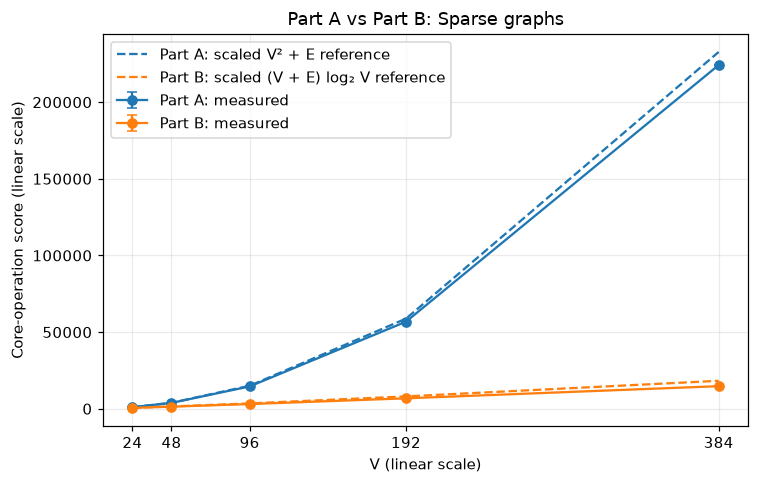

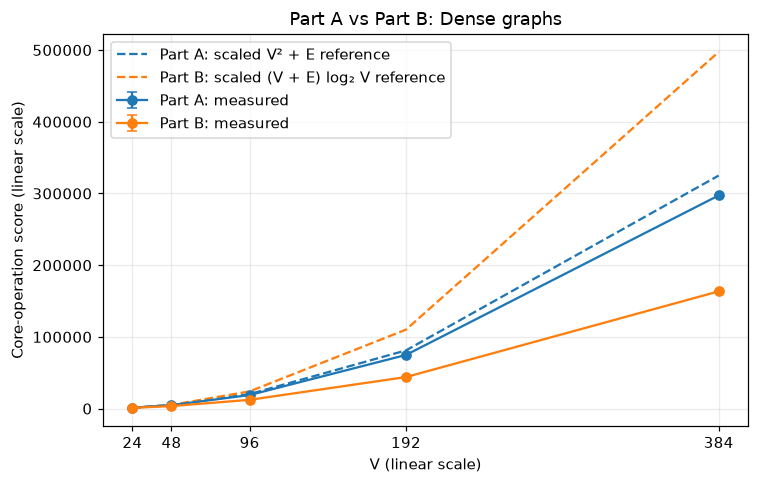

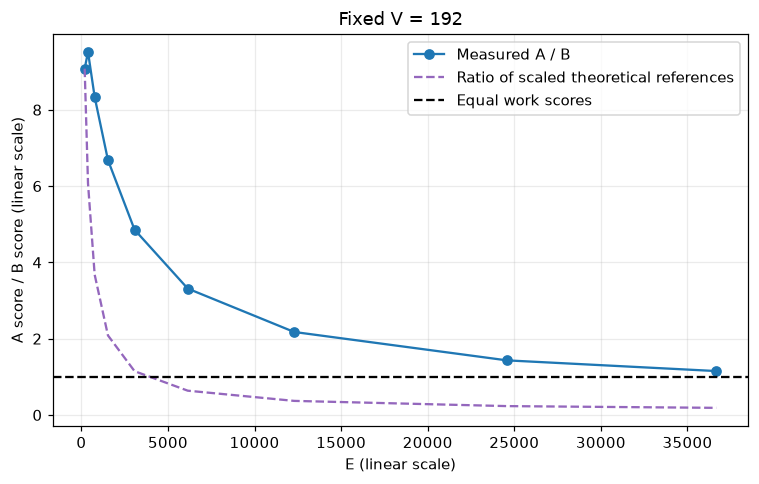

Ratios greater than 1 mean Part B has a smaller abstract work score.
sparse, V=384, E=1536: A=224,192, B=14,737, A/B=15.21; smaller score: Part B.
dense, V=384, E=73536: A=297,284, B=163,496, A/B=1.82; smaller score: Part B.


array_comparisons  matrix_probes  list_entries  \
family algorithm                                                   
dense  A                    73536.0       147456.0           0.0   
       B                        0.0            0.0       73536.0   
sparse A                    73536.0       147456.0           0.0   
       B                        0.0            0.0        1536.0   

                  relax_checks  distance_updates  heap_comparisons  heap_swaps  
family algorithm                                                                
dense  A               73536.0            1603.7               0.0         0.0  
       B               73536.0            1603.7            8228.7      3836.0  
sparse A                1536.0             511.7               0.0         0.0  
       B                1536.0             511.7            6394.7      3095.3

In [10]:
comparison = summary_a.merge(summary_b, on=['sweep', 'family', 'V', 'E'], suffixes=('_A', '_B'))
comparison['A_over_B'] = comparison.mean_ops_A / comparison.mean_ops_B
display(comparison[['sweep', 'family', 'V', 'E', 'mean_ops_A', 'mean_ops_B',
                    'A_over_B']].round(3))

def theoretical_references(subset):
    # Normalize each growth function to its own first measured point.
    raw_a = (subset.V**2 + subset.E).to_numpy(dtype=float)
    raw_b = ((subset.V + subset.E) * np.log2(subset.V)).to_numpy(dtype=float)
    reference_a = raw_a * subset.mean_ops_A.iloc[0] / raw_a[0]
    reference_b = raw_b * subset.mean_ops_B.iloc[0] / raw_b[0]
    return reference_a, reference_b


for family in ('sparse', 'dense'):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    subset = comparison[(comparison.sweep == 'V sweep') & (comparison.family == family)]
    for label, color in (('A', 'tab:blue'), ('B', 'tab:orange')):
        ax.errorbar(subset.V, subset[f'mean_ops_{label}'],
                    yerr=subset[f'sd_ops_{label}'], marker='o', capsize=3, color=color, label=f'Part {label}: measured')
    reference_a, reference_b = theoretical_references(subset)
    ax.plot(subset.V, reference_a, '--', color='tab:blue',
            label='Part A: scaled V² + E reference')
    ax.plot(subset.V, reference_b, '--', color='tab:orange',
            label='Part B: scaled (V + E) log₂ V reference')
    ax.set(xscale='linear', yscale='linear', xlabel='V (linear scale)', ylabel='Core-operation score (linear scale)', title='Part A vs Part B: ' + family.capitalize() + ' graphs')
    ax.set_xticks(subset.V, labels=subset.V.astype(str))
    ax.minorticks_off()
    ax.legend()
    plt.tight_layout()
    plt.show()
fig, ax = plt.subplots(figsize=(7, 4.5))
subset = comparison[comparison.sweep == 'E sweep']
ax.plot(subset.E, subset.A_over_B, 'o-', label='Measured A / B')
reference_a, reference_b = theoretical_references(subset)
ax.plot(subset.E, reference_a / reference_b, '--', color='tab:purple',
        label='Ratio of scaled theoretical references')
ax.axhline(1, color='black', linestyle='--', label='Equal work scores')
ax.set(xlabel='E (linear scale)', ylabel='A score / B score (linear scale)', title=f'Fixed V = {FIXED_V}')
ax.legend()
plt.tight_layout()
plt.show()

print('Ratios greater than 1 mean Part B has a smaller abstract work score.')
for family in ('sparse', 'dense'):
    row = comparison[(comparison.sweep == 'V sweep') & (comparison.family == family)].iloc[-1]
    winner = 'A' if row.mean_ops_A < row.mean_ops_B else 'B'
    print(f'{family}, V={int(row.V)}, E={int(row.E)}: '
          f'A={row.mean_ops_A:,.0f}, B={row.mean_ops_B:,.0f}, '
          f'A/B={row.A_over_B:.2f}; smaller score: Part {winner}.')

# Show the mechanism behind the comparison at the largest graph size.
components = ['array_comparisons', 'matrix_probes', 'list_entries', 'relax_checks',
              'distance_updates', 'heap_comparisons', 'heap_swaps']
largest = pd.concat([results_a.assign(algorithm='A'), results_b.assign(algorithm='B')])
display(largest[largest.V == max(VERTICES)].groupby(['family', 'algorithm'])[components].mean().round(1))

### A dense graph that needs many distance updates

In the random-graph experiment at $V = 384$, Part B used about **15.21 times fewer counted operations** on sparse graphs and **1.82 times fewer** on dense graphs.

To see why Part A can also win, we use a specially constructed dense graph. Its edge weights make the algorithm find shorter routes repeatedly, so many distance updates are needed.

Both algorithms check the same edges. **Part A just writes each new distance; Part B also has to fix the heap.** Those extra heap updates can make Part B do more work.

The code below creates this graph and compares the operation counts. It is a specific example of frequent updates, rather than a claim that Part A wins on every dense graph.


In [11]:
def dense_update_graph(n):
    return Graph(n, tuple(
        (u, v, 1 if v == u + 1 else (2 * n - 2 * u + v if u < v else 2 * n))
        for u in range(n) for v in range(n) if u != v
    ))

update_rows = []
for n in (48, 96, 192, 384):
    graph = dense_update_graph(n)
    check_graph(graph, 0)
    da, _, ca = dijkstra_matrix(to_adjacency_matrix(graph), 0)
    db, _, cb = dijkstra_list(to_adjacency_list(graph), 0)
    assert da == db == list(range(n))
    assert ca.distance_updates == cb.distance_updates == n * (n - 1) // 2
    update_rows.append({'V': n, 'E': graph.m, 'R': ca.distance_updates,
                        'A_score': ca.total, 'B_score': cb.total,
                        'A_over_B': ca.total / cb.total})
update_results = pd.DataFrame(update_rows)
display(update_results.round(3))
last = update_results.iloc[-1]
print(f'High-update dense graph, V={int(last.V)}: '
      f'A={last.A_score:,.0f}, B={last.B_score:,.0f}, A/B={last.A_over_B:.3f}.')
print('A/B below 1 means Part A has the smaller score under our counting model.')

,V,E,R,A_score,B_score,A_over_B
0,48,2256,1128,6960,8491,0.820
1,96,9120,4560,27744,33406,0.831
2,192,36672,18336,110784,131878,0.840
3,384,147072,73536,442752,522916,0.847


High-update dense graph, V=384: A=442,752, B=522,916, A/B=0.847.
A/B below 1 means Part A has the smaller score under our counting model.


The constructed graph shows why frequent distance updates can favor Part A. The random dense graphs favor Part B instead.

**Takeaway:** Part B has the better bound for sparse graphs; Part A has the better worst-case bound for dense graphs. The measured result depends on how much work the particular graph causes.


### Conclusions

1. **Part A: $O(V^2)$.** It processes $V$ vertices, repeatedly scanning the queue and a full matrix row. Sparse graphs still pay for these scans.
2. **Part B: $O((V + E)\log V)$.** It visits existing edges and uses heap operations that cost $O(\log V)$. For sparse graphs, this becomes $O(V\log V)$.
3. **For dense graphs, Part A has the better worst-case bound.** Part B can still use fewer operations on some inputs when few heap updates are needed.
4. **The experiments support the explanation of where the work goes.** They count operations, not elapsed seconds, and cover a limited range of graph sizes.

These bounds describe Dijkstra after the graph representation is built. If conversion is included, creating the matrix adds $O(V^2 + E)$ and creating the adjacency lists adds $O(V + E)$.

**References:** [Project 2 brief](Project%202.pdf), parts (a)–(c); [Shortest-path slides](06_ShortestPath.pdf), slides 9–10 (initialization and relaxation), 13 (Bellman–Ford), and 15–18 (Dijkstra).
